In [4]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()

while not (project_root / "main.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set to:", project_root)

Working directory set to: /Users/navidv/GitHub/QuEP


In [9]:
%%writefile input/Zeus2e16.py
#This line will create betatron_example.py input file in the subfolder 'input'.

simulation_name = 'QUASI3D'  
#Explanation in README file. All simulations should have this as simulation name

shape = 'single'    
#betatron test only uses a singlular electron. See other options in README file for other sims

iterations = 4000000
#Iterations refers to the amount of times the code is run. The input conditions are put into equations using main.py.
#A high number of iterations will have less space between each 't' value used which will have increased clarity in graphs

mode = -1 
#mode 0 is the wakefield, mode 1 is the laser, mode -1 is both. Betatron is to see electron in wakefield

#If calculations includes laser, include the region of laser (not needed if mode =0)
laser_A_enabled = True
# Laser region in xi, in c/omega_p units.
# Order does not matter; the code will sort them.
laser_xi_start = -0.3
laser_xi_end = 0.3


fname = "Zeus2e16.npz"
#main.py will put the data from the simulation into this file. name it whatever you want your data file to be

debugmode = True
#debugmode should only be true for single electron simulations (I'm not actually sure why)


# Probe centered at the following initial coordinates (in c/w_p):
#See figure 3.1 in Evan Trommer's thesis. The goal is to put the electron in line with the peak of the second bump of the field
#so while xi_c here is fairly fixed y_c can be any range of values still within the bubble
x_c = 0 #
y_c = 0.1 #
xi_c = 0.3

# Initial momentum
#set initial transverse momentum to zero and pz_0=20 (or any other number)
px_0 = 0  
py_0 = 0
pz_0 = 0

# Screen Distances (from z-axis of plasma cell, in mm):
x_s = [10, 50, 100, 250, 500]

# Shape Parameters (Radius or Side Length, in c/w_p):
s1 = 1 # In y
s2 = 1 # In xi

# Densities
#you only have a single electron so there should just be one when you count on any axis
ydensity = 1
xidensity = 1
xdensity = 1 # Probe width - single layer
resolution = None 

#Simulation specific parameters
simulation_name = "QUASI3D"
quasi_id = "000148"
quasi_data_dir = "data/OSIRIS/Zeus2e16"
quasi_density = 2e22
quasi_propagation_speed = 1.0
dt_safety_factor = 0.45

Overwriting input/Zeus2e16.py


In [10]:
#make sure to run from ~/GitHub/QuEP
%reset -f
%run main.py input.Zeus2e16

Start Time:  21:33:36
Using initial conditions from  input.Zeus2e16
Using user-specified laser region:
  xi range: -0.3 0.3
  clipped xi range: -0.3 0.3
  index range: 10368 11231
Probe initialized...
Number of objects: 1
Using user-specified laser region:
  xi range: -0.3 0.3
  clipped xi range: -0.3 0.3
  index range: 10368 11231
Using Debug Mode...
Tracking quit due to particle leaving cell
Debug object created...
End Time:  21:33:42
Duration:  0.0953055183092753  min
Debug object saved to data/Zeus2e16-DEBUG.obj


In [2]:
%reset -f

import gc
import importlib
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

# Make sure imports work when the notebook is run from the project root.
project_root = Path.cwd()
print("Working directory set to:", project_root)


# -----------------------------------------------------------------------------
# Load the user input file
# -----------------------------------------------------------------------------
# Use the module name, not the .py or .npz filename.
# For input/betatron_tutorial_input.py, use "input.betatron_tutorial_input" if
input_module = "input.Zeus2e16"
init = importlib.import_module(input_module)

# -----------------------------------------------------------------------------
# Configure the Quasi3D field infrastructure
# -----------------------------------------------------------------------------
import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load the debug trajectory object
# -----------------------------------------------------------------------------
debug_file = project_root / "data" / "Zeus2e16-DEBUG.obj"

with open(debug_file, "rb") as file:
    debug_loaded = pickle.load(file)

# main.py saves Debug as a one-element list/tuple in this tutorial case.
debug = debug_loaded[0] if isinstance(debug_loaded, (list, tuple)) else debug_loaded

print(f"Loaded input module: {init.__name__}")
print(f"Loaded debug file:   {debug_file}")
print("\nThe Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Using laser vector-potential region:
  xi range: -0.3 0.3
  index range: 10368 11231
Loaded input module: input.Zeus2e16
Loaded debug file:   /Users/navidv/GitHub/QuEP/data/Zeus2e16-DEBUG.obj

The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 13056)
y_dat                 type=ndarray          shape=(1, 13056)
z_dat                 type=ndarray          shape=(1, 13056)
xi_dat                type=ndarray          shape=(1, 13056)
Fx_dat                type=ndarray          shape=(1, 13056)
Fy_dat                type=ndarray          shape=(1, 13056)
Fz_dat                type=ndarray          shape=(1, 13056)
px_dat                type=ndarray          shape=(1, 13056)
py_dat                type=ndarray          shape=(1, 13056)
pz_dat                type=ndarray          shape=(1, 13056)


# ZEUS Case: Single-Electron Trajectory Tracking

This notebook analyzes a ZEUS-relevant near-infrared laser wakefield case with the following plasma and laser parameters:

$$
n_e = 2 \times 10^{16}\ \mathrm{cm}^{-3}, \qquad
\lambda_0 = 0.8\ \mu\mathrm{m}, \qquad
w_0 = 75\ \mu\mathrm{m},
$$

$$
a_0 = 3.66, \qquad
\tau = 25\ \mathrm{fs}.
$$

In normalized plasma units, this corresponds to

$$
k_p w_0 = 1.99, \qquad
k_p c \tau = 0.199.
$$

This notebook calculates and visualizes a **single-electron trajectory** in the wakefield generated by this ZEUS parameter set. It is intended as a lightweight case for inspecting the fields, forces, and particle motion for one representative test electron. Multi-electron trajectory tracking with multi-core processing on a personal computer is available in the `ZEUS2e16_multiprocessing` notebook in the same folder.

In [12]:
#Defining functions that allows fields to be called as needed
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from a DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay debug trajectories."""
    r_dat, xi_dat = get_r_xi_from_debug(debug)

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for i in range(r_dat.shape[0]):
        ax.plot(
            xi_dat[i, :],
            r_dat[i, :],
            color="black",
            linewidth=1.5,
            label="debug trajectory" if i == 0 else None,
        )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if r_dat.shape[0] > 0:
        ax.legend(loc="best")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


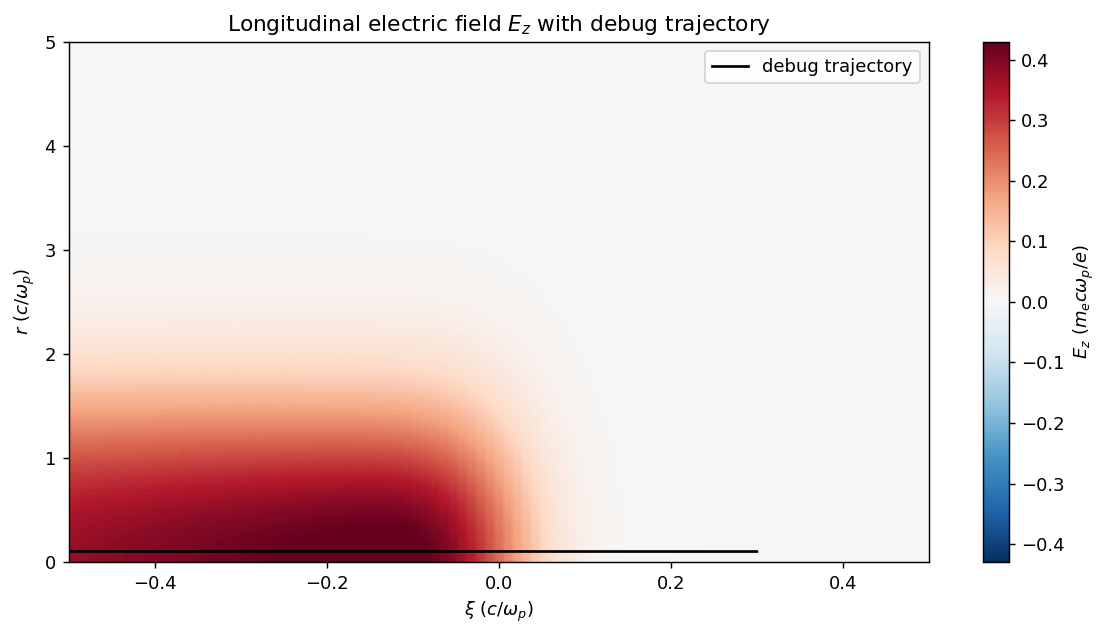

In [13]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debug,
    title=r"Longitudinal electric field $E_z$ with debug trajectory",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    # xlim=(-5, 6),
    xlim=(-0.5, 0.5),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)

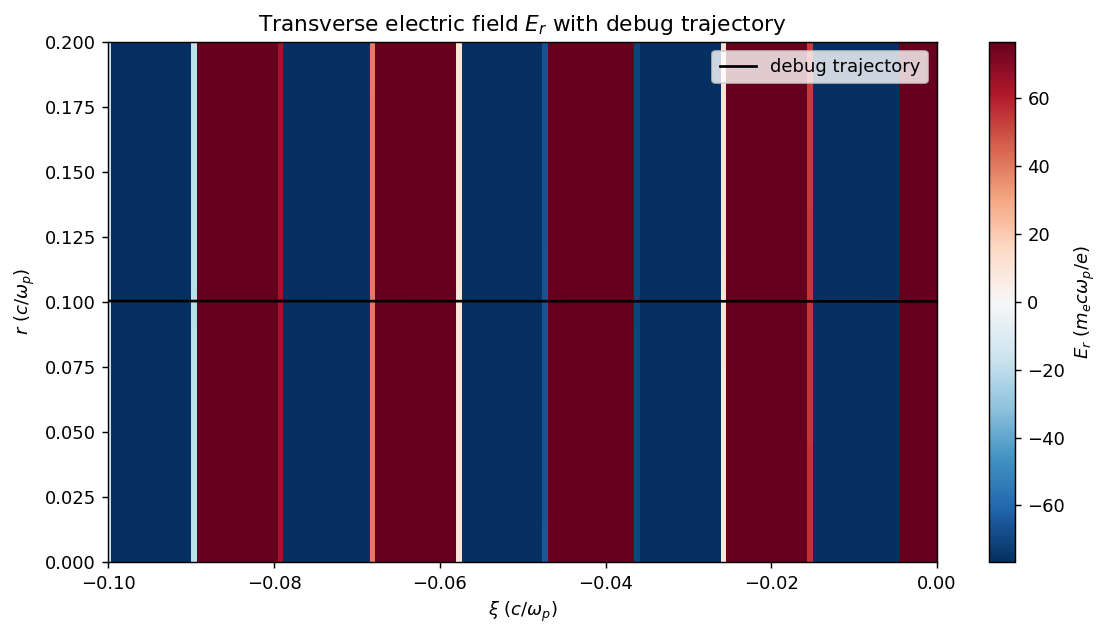

In [15]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    debug,
    title=r"Transverse electric field $E_r$ with debug trajectory",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-0.1, 0),
    # ylim=(0, 5),
    ylim=(0, 0.2),
)

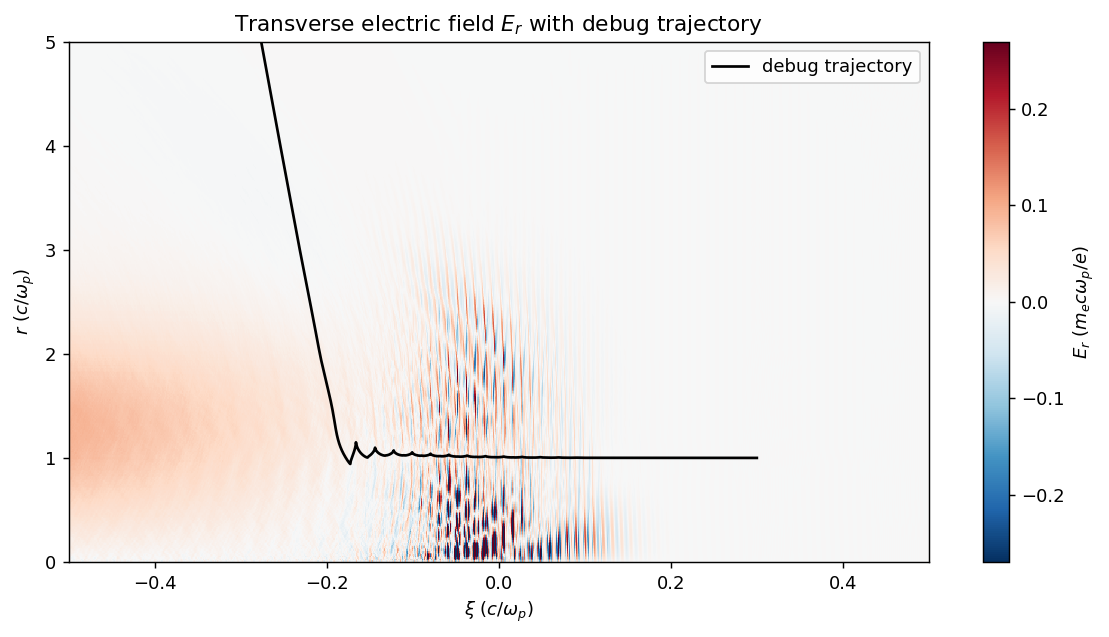

In [27]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M0,
    debug,
    title=r"Transverse electric field $E_r$ with debug trajectory",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-0.5, 0.5),
    ylim=(0, 5),
)

In [1]:
# Diagnostic: check E/B cancellation for the laser mode.
# Uses only xi values inside the available Quasi3D field domain.

import numpy as np
import matplotlib.pyplot as plt

# Choose where to sample the laser fields.
# phi = 0 means x = r and y = 0.
r0 = 0.5
x0 = r0
y0 = 0.0

# Available xi range common to the staggered grids.
xi_min_grid = max(sim.xiaxis_1[0], sim.xiaxis_2[0])
xi_max_grid = min(sim.xiaxis_1[-1], sim.xiaxis_2[-1])

print("Available xi range:")
print("  xiaxis_1:", sim.xiaxis_1[0], sim.xiaxis_1[-1])
print("  xiaxis_2:", sim.xiaxis_2[0], sim.xiaxis_2[-1])
print("  common :", xi_min_grid, xi_max_grid)

# Choose a requested diagnostic range, then clip it to the available grid.
xi_min_request = -15
xi_max_request = 5

xi_min = max(xi_min_request, xi_min_grid)
xi_max = min(xi_max_request, xi_max_grid)

if xi_min >= xi_max:
    raise ValueError(
        f"Requested xi range [{xi_min_request}, {xi_max_request}] "
        f"does not overlap field range [{xi_min_grid}, {xi_max_grid}]."
    )

xi_vals = np.linspace(xi_min, xi_max, 3000)

Ex_vals = []
By_vals = []
Ex_minus_By = []
Ex_plus_By = []

for xi in xi_vals:
    r = np.sqrt(x0**2 + y0**2)

    Ex = sim.EField(2, x0, y0, xi, r, mode=1)
    By = sim.BField(3, x0, y0, xi, r, mode=1)

    Ex_vals.append(Ex)
    By_vals.append(By)
    Ex_minus_By.append(Ex - By)
    Ex_plus_By.append(Ex + By)

Ex_vals = np.asarray(Ex_vals)
By_vals = np.asarray(By_vals)
Ex_minus_By = np.asarray(Ex_minus_By)
Ex_plus_By = np.asarray(Ex_plus_By)

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(xi_vals, Ex_vals, label=r"$E_x$")
plt.plot(xi_vals, By_vals, label=r"$B_y$")
plt.plot(xi_vals, Ex_minus_By, label=r"$E_x - B_y$")
plt.plot(xi_vals, Ex_plus_By, label=r"$E_x + B_y$", linestyle="--")

plt.xlabel(r"$\xi$ $(c/\omega_p)$")
plt.ylabel("normalized field")
plt.title(r"Laser-mode $E/B$ cancellation diagnostic at $\phi = 0$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.3, 0.3)
plt.ylim(500, 800)
plt.show()

NameError: name 'sim' is not defined

In [7]:
# Convert normalized laser electric field from eE/(m_e c omega_p)
# to the usual laser a0-like normalization eE/(m_e c omega_0).

C = 299792458  # m/s
laser_wavelength = 800e-9  # meters

omega_p = sim.getPlasFreq()
omega_0 = 2 * np.pi * C / laser_wavelength

Ex_a0_units = Ex_vals * omega_p / omega_0
By_a0_units = By_vals * omega_p / omega_0
Ex_minus_By = Ex_minus_By * omega_p / omega_0

print("omega_p =", omega_p)
print("omega_0 =", omega_0)
print("omega_p / omega_0 =", omega_p / omega_0)

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(xi_vals, Ex_a0_units, label=r"$E_x \, \omega_p/\omega_0$")
plt.plot(xi_vals, By_a0_units, label=r"$B_y \, \omega_p/\omega_0$")
plt.plot(xi_vals, Ex_minus_By, label=r"$E_x-B_y \, \omega_p/\omega_0$")
plt.xlabel(r"$\xi$ $(c/\omega_p)$")
plt.ylabel(r"$eE/(m_e c \omega_0)$")
plt.title(r"Laser fields in $a_0$-like normalization")
plt.xlim(-0.3, 0.3)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'Ex_vals' is not defined

In [9]:
import inspect

print("EField uses interp2:", "interp2" in inspect.getsource(sim.EField))

print("BField uses interp2:", "interp2" in inspect.getsource(sim.BField))

print("BForce uses interp2:", "interp2" in inspect.getsource(sim.BForce))

EField uses interp2: True
BField uses interp2: True
BForce uses interp2: True


In [8]:
# Compare raw By from field file with By from curl(A)

r0 = 0.5
x0 = r0
y0 = 0.0

xi_vals = np.linspace(sim.Laser_xi_min, sim.Laser_xi_max, 2000)

Ex_vals = []
By_raw_vals = []
By_A_vals = []

for xi in xi_vals:
    r = np.sqrt(x0**2 + y0**2)

    Ex_vals.append(sim.EField(2, x0, y0, xi, r, mode=1))
    By_raw_vals.append(sim.BField(3, x0, y0, xi, r, mode=1))
    By_A_vals.append(sim.BFieldLaserFromA(3, x0, y0, xi, r))

Ex_vals = np.asarray(Ex_vals)
By_raw_vals = np.asarray(By_raw_vals)
By_A_vals = np.asarray(By_A_vals)

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(xi_vals, Ex_vals, label=r"$E_x$")
plt.plot(xi_vals, By_raw_vals, label=r"$B_y$ raw")
plt.plot(xi_vals, By_A_vals, "--", label=r"$B_y$ from $\nabla \times A$")
plt.plot(xi_vals, Ex_vals - By_A_vals, label=r"$E_x - B_y(A)$")
plt.xlabel(r"$\xi$ $(c/\omega_p)$")
plt.ylabel("normalized field")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: module 'include.simulations.useQuasi3D' has no attribute 'Laser_xi_min'